# Components NGMS icon

In [1]:
import sys
sys.path.append('/work/mh0731/m300876/package/')
import icons
import intake
import matplotlib.pyplot as plt
import healpy as hp
import xarray as xr
import numpy as np
import easygems.healpix as egh
import seaborn as sns

/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
icons.prepare_cpu(memory='100GB')

Number of CPUs: 256, number of threads: 256, number of workers: 1, processes: False


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /user/m300876/levante-spawner-preset//proxy/42811/status,
Dashboard: /user/m300876/levante-spawner-preset//proxy/42811/status,Workers: 1
Total threads: 256,Total memory: 93.13 GiB
Status: running,Using processes: False
Comm: inproc://136.172.122.122/2431658/1,Workers: 1
Dashboard: /user/m300876/levante-spawner-preset//proxy/42811/status,Total threads: 256
Started: Just now,Total memory: 93.13 GiB
Comm: inproc://136.172.122.122/2431658/4,Total threads: 256
Dashboard: /user/m300876/levante-spawner-preset//proxy/42179/status,Memory: 93.13 GiB
Nanny: None,


### Predefined functions

In [3]:
#### componenets of NGMS
g = 9.81
cp = 1005 ## J kg-1 K-1
Lv = 2500.93e3

### Calculate omega 
def calc_evapor(ds):
    epsilon = 0.622 #ratio of molar masses of vapor and dry air (0.622)
    return (ds.hus*ds.pressure)/(epsilon + (1-epsilon)*ds.hus)

def calc_pdry(ds):
    return ds.pressure - calc_evapor(ds)

def calc_density(ds):
    Md = 0.0289652  #molar mass of dry air, 0.0289652 kg/mol
    Mv = 0.018016 # molar mass of water vapor, 0.018016 kg/mol
    R = 8.31446 # universal gas constant, 8.31446 J/(K·mol)
    return (calc_pdry(ds)*Md + calc_evapor(ds)*Mv)/(R*ds.ta)

def calc_omega(ds):
    return -calc_density(ds)*ds.wa*g

### Energy components
def calc_mse(ds):
    cv = 719 ## J kg-1 K-1
    Lf = 334e3
    return cp*ds.ta + Lv*ds.hus + g*ds.zg

def calc_dhdz(ds):
    mse = calc_mse(ds) 
    return mse.differentiate(coord='pressure')

def calc_int_wdhdz(ds):
    return (calc_omega(ds)*calc_dhdz(ds)/g).fillna(0).integrate(coord='pressure')

def calc_mseflux(ds):
    return calc_mse(ds)*ds.ua, calc_mse(ds)*ds.va

def calc_int_mseflux(ds):
    umseflux,vmseflux =  calc_mseflux(ds)
    return (umseflux/g).fillna(0).integrate(coord='pressure').compute(), (vmseflux/g).fillna(0).integrate(coord='pressure').compute()

### Water components

def calc_qflux(ds):
    return ds.hus*ds.ua, ds.hus*ds.va

def calc_int_qflux(ds):
    uqflux,vqflux =  calc_qflux(ds)
    return (uqflux/g).fillna(0).integrate(coord='pressure').compute(), (vqflux/g).fillna(0).integrate(coord='pressure').compute()

In [4]:
### derivates in healpix

def nest2ring_index(ds):
    nside= hp.npix2nside(ds.cell.size)
    return np.array([hp.ring2nest(nside, i) for i in ds.cell.values])

def compute_hder(ds, ring_index):
    """computes the horizontal derivatives of any variable (1 vertical level, 1 time) using spherical harmonics"""
    nside= hp.npix2nside(ds.cell.size)
    var_alm = hp.sphtfunc.map2alm(ds.sel(cell = ring_index).values)
    der_arr = hp.sphtfunc.alm2map_der1(var_alm, nside)
    return der_arr[1, :]*-1, der_arr[2, :] # dvar_dtheta (co-lat), dvar_dphi (lon)

def convert2hp(narray,ds):
    nested_array = hp.reorder(narray,inp='RING',out='NESTED',r2n=True)
    xarray_hp = xr.DataArray(nested_array,dims=["cell"],
        coords=dict(
        lon=(["cell"], ds.lon.values),
        lat=(["cell"], ds.lat.values),
        ),)
    return xarray_hp

def compute_derivatives(ds):
    ring_index = nest2ring_index(ds)
    vardy,vardx = compute_hder(ds, ring_index)
    dsdx = convert2hp(vardx,ds)
    dsdy = convert2hp(vardy,ds)
    return dsdx,dsdy

def compute_flux_div(uflux, vflux):
    ring_index = nest2ring_index(uflux)
    _, dua_dphi = compute_hder(uflux, ring_index)
    dva_dtheta, _  = compute_hder(vflux, ring_index)
    
    dua_dphi_hp = convert2hp(dua_dphi,uflux)
    dva_dtheta_hp = convert2hp(dva_dtheta,vflux)
    va_tanlat = vflux * np.tan(np.deg2rad(vflux.lat.values))
    
    return (dua_dphi_hp + dva_dtheta_hp - va_tanlat) / 6378e3

In [5]:
### Location mask
def tropics(ds):
    return np.abs(ds.lat) <= 30.1

def equator(ds):
    return np.abs(ds.lat) <= 5.1

def equator2(ds):
    return (ds.lat >= 2.1) & (ds.lat <= 12.1)

def eq_wpacific(ds):
    return equator(ds) & (ds.lon>150) & (ds.lon<170)

def eq_epacific(ds):
    return equator2(ds) & (ds.lon>240) & (ds.lon<260)

## Calling data

In [79]:
%%time
### ICON
current_location = "online"
cat = cat = intake.open_catalog(
    "https://digital-earths-global-hackathon.github.io/catalog/catalog.yaml")[current_location]
exp_name = "icon_d3hp003"
experiment = cat[exp_name]
time_slice = slice("2020-07-01", "2020-07-31")
ds_icon = (
    experiment(zoom=6, time_method='inst', time="PT6H", chunks="auto")
    .to_dask()
    .pipe(egh.attach_coords)
    .sel(time=time_slice)
)

CPU times: user 224 ms, sys: 5 ms, total: 229 ms
Wall time: 378 ms


In [80]:
%%time
### NICAM
exp_name = "nicam_gl11"
experiment = cat[exp_name]
time_slice = slice("2020-07-01", "2020-07-31")
ds_nicam = (
    experiment(zoom=6, time="PT6H", chunks="auto")
    .to_dask()
    .sel(time=time_slice)
).rename({'lev':'pressure'})

ds_nicam = ds_nicam.assign_coords(
    lat=(("cell",), ds_icon.lat.values, {"units": "degree_north"}),
    lon=(("cell",), ds_icon.lon.values, {"units": "degree_east"}),
    pressure = ds_nicam.pressure.values*100
)

CPU times: user 95.2 ms, sys: 4.54 ms, total: 99.7 ms
Wall time: 1.92 s


In [81]:
%%time
### UM
exp_name = "um_glm_n2560_RAL3p3"
experiment = cat[exp_name]
time_slice = slice("2020-07-01", "2020-07-31")
ds_um = (
    experiment(zoom=6, time="PT3H", chunks="auto")
    .to_dask()
    .sel(time=time_slice)
)

ds_um = ds_um.assign_coords(
    lat=(("cell",), ds_icon.lat.values, {"units": "degree_north"}),
    lon=(("cell",), ds_icon.lon.values, {"units": "degree_east"}),
    pressure = ds_um.pressure.values*100
)

CPU times: user 92.1 ms, sys: 3.54 ms, total: 95.6 ms
Wall time: 747 ms


## Calculate MSE (h), $\omega$, $\int\omega\frac{\mathrm{d}h}{\mathrm{d}p}\mathrm{d}p$

In [82]:
%%time
wdhdz_int_icon = calc_int_wdhdz(ds_icon.sel(pressure=slice(5000,100000))).compute()
wdhdz_int_nicam = (calc_int_wdhdz(ds_nicam.sel(pressure=slice(100000,5000))).compute()*-1)
wdhdz_int_um = calc_int_wdhdz(ds_um.sel(pressure=slice(5000,100000)).chunk({'pressure':5})).compute()

CPU times: user 44.5 s, sys: 38.3 s, total: 1min 22s
Wall time: 42.2 s


In [83]:
wdhdz_int_mon_icon = wdhdz_int_icon.resample(time='1M').mean()
wdhdz_int_mon_nicam = wdhdz_int_nicam.resample(time='1M').mean()
wdhdz_int_mon_um = wdhdz_int_um.resample(time='1M').mean()

## Calculate  $\int\overrightarrow{V}q\mathrm{d}p$

In [84]:
%%time
uqflux_int_icon,vqflux_int_icon = calc_int_qflux(ds_icon)
uqflux_int_nicam,vqflux_int_nicam = calc_int_qflux(ds_nicam)
uqflux_int_um,vqflux_int_um = calc_int_qflux(ds_um)

CPU times: user 42.7 s, sys: 21.2 s, total: 1min 3s
Wall time: 42.4 s


In [85]:
uqflux_int_mon_icon = uqflux_int_icon.resample(time='1M').mean()
vqflux_int_mon_icon = vqflux_int_icon.resample(time='1M').mean()

uqflux_int_mon_nicam = uqflux_int_nicam.resample(time='1M').mean()
vqflux_int_mon_nicam = vqflux_int_nicam.resample(time='1M').mean()

uqflux_int_mon_um = uqflux_int_um.resample(time='1M').mean()
vqflux_int_mon_um = vqflux_int_um.resample(time='1M').mean()

## Calculate  $\nabla.\int\overrightarrow{V}q\mathrm{d}p$

In [86]:
%%time
div_flux = [];
datau=uqflux_int_mon_icon
datav=vqflux_int_mon_icon
for time_idx in range(datau.time.shape[0]):
    div = compute_flux_div(datau.isel(time=time_idx),datav.isel(time=time_idx))
    div_flux.append(div)
    
divqflux_int_mon_icon = xr.concat(div_flux,dim=datau.time)

CPU times: user 18.2 s, sys: 1.53 s, total: 19.7 s
Wall time: 449 ms


In [87]:
%%time
div_flux = [];
datau=uqflux_int_mon_nicam
datav=vqflux_int_mon_nicam
for time_idx in range(datau.time.shape[0]):
    div = compute_flux_div(datau.isel(time=time_idx),datav.isel(time=time_idx))
    div_flux.append(div)
    
divqflux_int_mon_nicam = xr.concat(div_flux,dim=datau.time)

CPU times: user 46 s, sys: 1.57 s, total: 47.6 s
Wall time: 454 ms


In [88]:
%%time
div_flux = [];
datau=uqflux_int_mon_um
datav=vqflux_int_mon_um
for time_idx in range(datau.time.shape[0]):
    div = compute_flux_div(datau.isel(time=time_idx),datav.isel(time=time_idx))
    div_flux.append(div)
    
divqflux_int_mon_um = xr.concat(div_flux,dim=datau.time)

CPU times: user 46.3 s, sys: 1.69 s, total: 48 s
Wall time: 442 ms


In [89]:
#%%time
#umseflux_int,vmseflux_int = calc_int_mseflux(ds_icon)
#mse_nicam = calc_mse(ds_nicam.sel(
#    pressure=slice(100000,5000))).where(tropics(ds_nicam)).compute()
#omega_nicam = calc_omega(ds_nicam.sel(
#    pressure=slice(100000,5000))).where(tropics(ds_nicam)).compute()


## Calculate  $\int\overrightarrow{V}q\mathrm{d}p$, $\int\overrightarrow{V}h\mathrm{d}p$

In [8]:
%%time
uqflux_int,vqflux_int = calc_int_qflux(ds_icon)
umseflux_int,vmseflux_int = calc_int_mseflux(ds_icon)

CPU times: user 49.5 s, sys: 30.5 s, total: 1min 19s
Wall time: 43.3 s


In [ ]:
#%%time
#uqflux_int_nicam,vqflux_int_nicam = calc_int_qflux(ds_nicam)
#umseflux_int_nicam,vmseflux_int_nicam = calc_int_mseflux(ds_nicam)

In [9]:
## Monthly Mean

In [26]:
uqflux_int_mon = uqflux_int.resample(time='1M').mean()
vqflux_int_mon = vqflux_int.resample(time='1M').mean()
umseflux_int_mon = umseflux_int.resample(time='1M').mean()
vmseflux_int_mon = vmseflux_int.resample(time='1M').mean()

In [67]:
wdhdz_int_mon_nicam = wdhdz_int_nicam.resample(time='1M').mean()

In [68]:
wdhdz_int_mon_um = wdhdz_int_um.resample(time='1M').mean()

## Calculate  $\nabla.\int\overrightarrow{V}q\mathrm{d}p$, $\nabla.\int\overrightarrow{V}h\mathrm{d}p$

In [28]:
%%time
### q
div_flux = [];
datau=uqflux_int_mon
datav=vqflux_int_mon
for time_idx in range(datau.time.shape[0]):
    div = compute_flux_div(datau.isel(time=time_idx),datav.isel(time=time_idx))
    div_flux.append(div)
    
divqflux_int = xr.concat(div_flux,dim=datau.time)

CPU times: user 7min 1s, sys: 19.2 s, total: 7min 20s
Wall time: 3.67 s


In [29]:
%%time
### h
div_flux = [];
datau=umseflux_int_mon
datav=vmseflux_int_mon
for time_idx in range(datau.time.shape[0]):
    div = compute_flux_div(datau.isel(time=time_idx),datav.isel(time=time_idx))
    div_flux.append(div)
    
divmseflux_int = xr.concat(div_flux,dim=datau.time)

CPU times: user 7min 4s, sys: 13.9 s, total: 7min 18s
Wall time: 3.97 s


### $\Gamma$,$\Gamma_\mathrm{v}$

In [90]:
gamma_v_mon_icon = wdhdz_int_mon_icon/(-divqflux_int_mon_icon*Lv)
gamma_v_mon_nicam = wdhdz_int_mon_nicam/(divqflux_int_mon_nicam*Lv)
gamma_v_mon_um = wdhdz_int_mon_um/(-divqflux_int_mon_um*Lv)

In [91]:
gamma_v_year_icon = wdhdz_int_mon_icon.mean('time')/(-divqflux_int_mon_icon*Lv).mean('time')
gamma_v_year_nicam = wdhdz_int_mon_nicam.mean('time')/(divqflux_int_mon_nicam*Lv).mean('time')
gamma_v_year_um = wdhdz_int_mon_um.mean('time')/(-divqflux_int_mon_um*Lv).mean('time')

In [92]:
gamma_year = divmseflux_int.mean('time')/(-divqflux_int*Lv).mean('time')
gamma_v_year = wdhdz_int_icon_mon.mean('time')/(-divqflux_int*Lv).mean('time')

NameError: name 'divmseflux_int' is not defined

## Plotting

In [93]:
import cartopy.crs as ccrs
import cartopy.feature as cf

### Predefined functions

In [94]:
def tropdmap(var,cbar_title=None, **kwargs):
    projection = ccrs.PlateCarree(central_longitude=-135.5808361)
    sns.set_context("paper")
    fig, ax = plt.subplots(
        figsize=(16/2.54, 16/2.54), subplot_kw={"projection": projection}, constrained_layout=True
    )
    ax1=fig.add_axes([0.3,0.3,0.45,0.06])
    ax.set_global()

    cs = egh.healpix_show(var, ax=ax, **kwargs)
    ax.set_ylim(-30,30)
    ax.spines.geo.set_visible(False)
    ax.coastlines(resolution='110m',linewidth=0.6)
    cb1=plt.colorbar(cs,extend='both',orientation='horizontal',cax=ax1)
    cb1.ax.set_xlabel(cbar_title)

In [95]:
def subplots(var,ax,titles=None,cbar=False,cbar_title=None,**kwargs):
    ax.set_global()
    cs = egh.healpix_show(var, ax=ax, **kwargs)
    ax.set_ylim(-30,30)
    ax.spines.geo.set_visible(False)
    ax.coastlines(resolution='110m',linewidth=0.6)
    ax.set_title(titles)
    if cbar==True:
        cb1=plt.colorbar(cs,extend='both',orientation='horizontal',cax=ax1)
        cb1.ax.set_xlabel(cbar_title)

## $\int\omega\frac{\mathrm{d}h}{\mathrm{d}p}\mathrm{d}p$, $\nabla.\int\overrightarrow{V}q\mathrm{d}p$ ,$\nabla.\int\overrightarrow{V}h\mathrm{d}p$

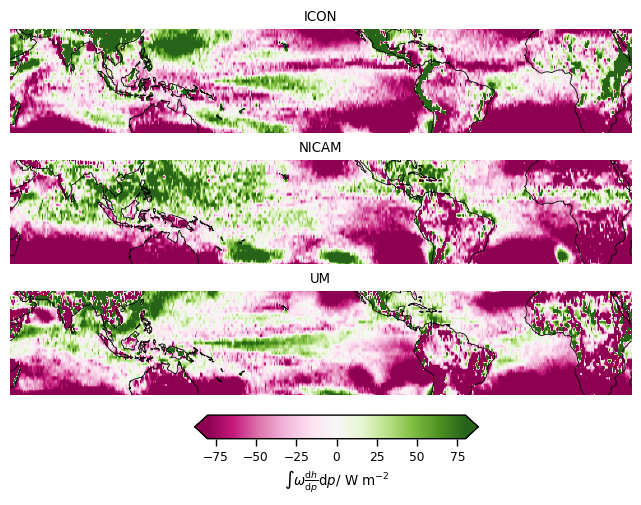

In [96]:
projection = ccrs.PlateCarree(central_longitude=-135.5808361)
sns.set_context("paper")
fig, ax = plt.subplots(nrows=3, ncols=1,
        figsize=(16/2.54, 10/2.54), subplot_kw={"projection": projection}, constrained_layout=True
    )

ax1=fig.add_axes([0.3,-0.1,0.45,0.06])
subplots(wdhdz_int_mon_icon.mean('time'),ax[0],titles='ICON',vmin=-80,vmax=80,cmap='PiYG')
subplots(wdhdz_int_mon_nicam.mean('time'),ax[1],titles='NICAM',vmin=-80,vmax=80,cmap='PiYG')
subplots(wdhdz_int_mon_um.mean('time'),ax[2],
         titles='UM',cbar=True,cbar_title=r'$\int\omega\frac{\mathrm{d}h}{\mathrm{d}p}\mathrm{d}p$/ W m$^{-2}$',
         vmin=-80,vmax=80,cmap='PiYG')

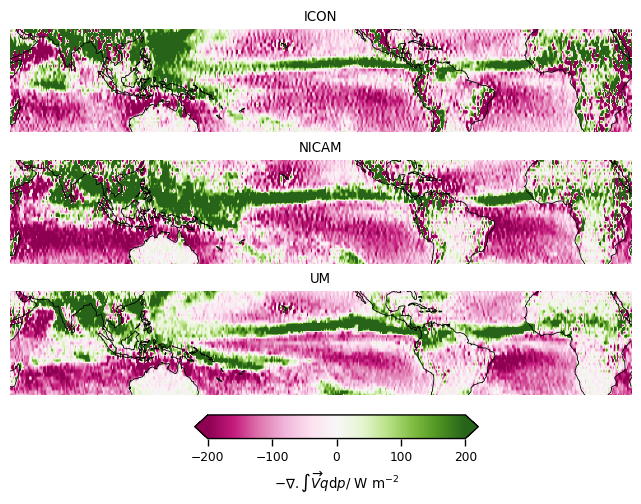

In [97]:
projection = ccrs.PlateCarree(central_longitude=-135.5808361)
sns.set_context("paper")


fig, ax = plt.subplots(nrows=3, ncols=1,
        figsize=(16/2.54, 10/2.54), subplot_kw={"projection": projection}, constrained_layout=True
    )
ax1=fig.add_axes([0.3,-0.1,0.45,0.06])
subplots(divqflux_int_mon_icon.mean('time')*Lv*-1,ax[0],titles='ICON',vmin=-200,vmax=200,cmap='PiYG')
subplots(divqflux_int_mon_nicam.mean('time')*Lv,ax[1],titles='NICAM',vmin=-200,vmax=200,cmap='PiYG')
subplots(divqflux_int_mon_um.mean('time')*Lv*-1,ax[2],
         titles='UM',cbar=True,cbar_title=r'$-\nabla.\int\overrightarrow{V}q\mathrm{d}p$/ W m$^{-2}$' ,
         vmin=-200,vmax=200,cmap='PiYG')

In [98]:
hist_wdhdp_icon_wpacific= np.histogram((wdhdz_int_mon_icon).where( 
    eq_wpacific(gamma_v_mon_icon) & (divqflux_int_mon_icon<0)),bins=np.arange(-150,150,5),
                                  density=False)

hist_wdhdp_nicam_wpacific= np.histogram((wdhdz_int_mon_nicam).where( 
    eq_wpacific(gamma_v_mon_nicam) & (divqflux_int_mon_nicam>0)),bins=np.arange(-150,150,5),
                                  density=False)

hist_wdhdp_um_wpacific= np.histogram((wdhdz_int_mon_um).where( 
    eq_wpacific(gamma_v_mon_um) & (divqflux_int_mon_um<0)),bins=np.arange(-150,150,5),
                                  density=False)

In [99]:
hist_divq_icon_wpacific= np.histogram((divqflux_int_mon_icon*Lv*-1).where( 
    eq_wpacific(gamma_v_mon_icon)),bins=np.arange(-300,700,20),
                                  density=False)

hist_divq_nicam_wpacific= np.histogram((divqflux_int_mon_nicam*Lv).where( 
    eq_wpacific(gamma_v_mon_nicam)),bins=np.arange(-300,700,20),
                                  density=False)

hist_divq_um_wpacific= np.histogram((divqflux_int_mon_um*Lv*-1).where( 
    eq_wpacific(gamma_v_mon_um)),bins=np.arange(-300,700,20),
                                  density=False)

In [100]:
hist_gamma_v_icon_wpacific= np.histogram((gamma_v_mon_icon).where( 
    eq_wpacific(gamma_v_mon_icon) & (divqflux_int_mon_icon<0)),bins=np.arange(-1.5,1.5,0.1),
                                  density=False)

hist_gamma_v_nicam_wpacific= np.histogram((gamma_v_mon_nicam).where( 
    eq_wpacific(gamma_v_mon_nicam) & (divqflux_int_mon_nicam>0)),bins=np.arange(-1.5,1.5,0.1),
                                  density=False)

hist_gamma_v_um_wpacific= np.histogram((gamma_v_mon_um).where( 
    eq_wpacific(gamma_v_mon_um) & (divqflux_int_mon_um<0)),bins=np.arange(-1.5,1.5,0.1),
                                  density=False)

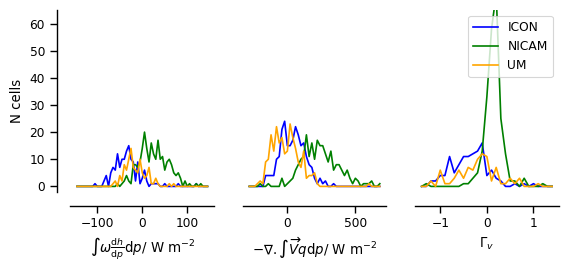

In [102]:
sns.set_context("paper")
fig = plt.figure(figsize=(16/2.54, 6/2.54), facecolor="white")
ax= fig.add_subplot(131)
plt.plot(hist_wdhdp_icon_wpacific[1][1:],hist_wdhdp_icon_wpacific[0],color='b')
plt.plot(hist_wdhdp_nicam_wpacific[1][1:],hist_wdhdp_nicam_wpacific[0],color='g')
plt.plot(hist_wdhdp_um_wpacific[1][1:],hist_wdhdp_um_wpacific[0],color='orange')
sns.despine(offset=10, ax=ax)
ax.set_ylim([-2,65])
ax.set_ylabel('N cells')
ax.set_xlabel(r'$\int\omega\frac{\mathrm{d}h}{\mathrm{d}p}\mathrm{d}p$/ W m$^{-2}$')

ax= fig.add_subplot(132)
plt.plot(hist_divq_icon_wpacific[1][1:],hist_divq_icon_wpacific[0],color='b')
plt.plot(hist_divq_nicam_wpacific[1][1:],hist_divq_nicam_wpacific[0],color='g')
plt.plot(hist_divq_um_wpacific[1][1:],hist_divq_um_wpacific[0],color='orange')
sns.despine(offset=10, ax=ax)
ax.set_ylim([-2,65])
ax.spines['left'].set_visible(False)
ax.set_yticks([])
ax.set_xlabel(r'$-\nabla.\int\overrightarrow{V}q\mathrm{d}p$/ W m$^{-2}$')

ax= fig.add_subplot(133)
plt.plot(hist_gamma_v_icon_wpacific[1][1:],hist_gamma_v_icon_wpacific[0],color='b',label='ICON')
plt.plot(hist_gamma_v_nicam_wpacific[1][1:],hist_gamma_v_nicam_wpacific[0],color='g',label='NICAM')
plt.plot(hist_gamma_v_um_wpacific[1][1:],hist_gamma_v_um_wpacific[0],color='orange',label='UM')
sns.despine(offset=10, ax=ax)
ax.set_ylim([-2,65])
ax.spines['left'].set_visible(False)
ax.set_yticks([])
ax.set_xlabel(r'$\Gamma_{v}$')
plt.legend()

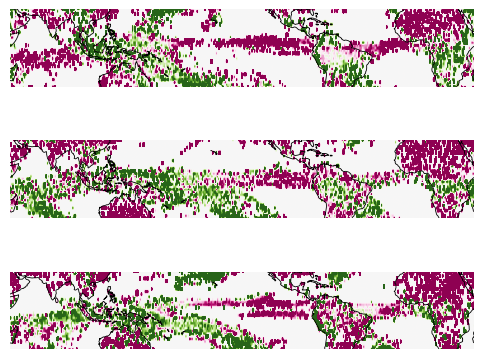

In [32]:
projection = ccrs.PlateCarree(central_longitude=-135.5808361)
sns.set_context("paper")


fig, ax = plt.subplots(nrows=3, ncols=1,
        figsize=(12/2.54, 10/2.54), subplot_kw={"projection": projection}, constrained_layout=True
    )
subplots(gamma_v_year_icon.where(divqflux_int_mon_icon.mean('time')<0,0),ax[0],vmin=-0.3,vmax=0.3,cmap='PiYG')
subplots(gamma_v_year_nicam.where(divqflux_int_mon_nicam.mean('time')>0,0),ax[1],vmin=-0.3,vmax=0.3,cmap='PiYG')
subplots(gamma_v_year_um.where(divqflux_int_mon_um.mean('time')<0,0),ax[2],vmin=-0.3,vmax=0.3,cmap='PiYG')

In [24]:
hist_wdhdp_icon_wpacific= np.histogram((wdhdz_int_mon_icon).where( 
    eq_wpacific(gamma_v_mon_icon) & (divqflux_int_mon_icon<0)),bins=np.arange(-150,150,5),
                                  density=True)

hist_wdhdp_nicam_wpacific= np.histogram((wdhdz_int_mon_nicam).where( 
    eq_wpacific(gamma_v_mon_nicam) & (divqflux_int_mon_nicam>0)),bins=np.arange(-150,150,5),
                                  density=True)

hist_wdhdp_um_wpacific= np.histogram((wdhdz_int_mon_um).where( 
    eq_wpacific(gamma_v_mon_um) & (divqflux_int_mon_um<0)),bins=np.arange(-150,150,5),
                                  density=True)

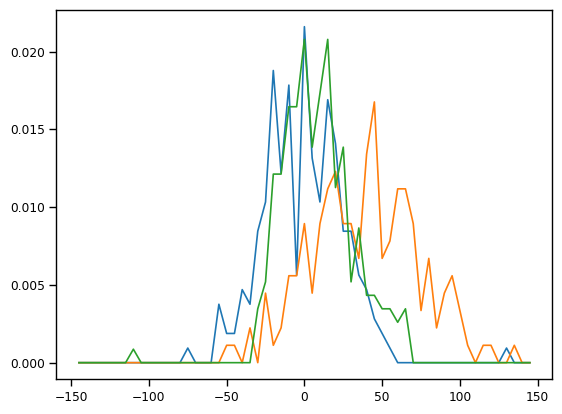

In [25]:
plt.plot(hist_wdhdp_icon_wpacific[1][1:],hist_wdhdp_icon_wpacific[0])
plt.plot(hist_wdhdp_nicam_wpacific[1][1:],hist_wdhdp_nicam_wpacific[0])
plt.plot(hist_wdhdp_um_wpacific[1][1:],hist_wdhdp_um_wpacific[0])

In [26]:
hist_divq_icon_wpacific= np.histogram((divqflux_int_mon_icon*Lv*-1).where( 
    eq_wpacific(gamma_v_mon_icon)),bins=np.arange(-700,700,20),
                                  density=True)

hist_divq_nicam_wpacific= np.histogram((divqflux_int_mon_nicam*Lv).where( 
    eq_wpacific(gamma_v_mon_nicam)),bins=np.arange(-700,700,20),
                                  density=True)

hist_divq_um_wpacific= np.histogram((divqflux_int_mon_um*Lv*-1).where( 
    eq_wpacific(gamma_v_mon_um)),bins=np.arange(-700,700,20),
                                  density=True)

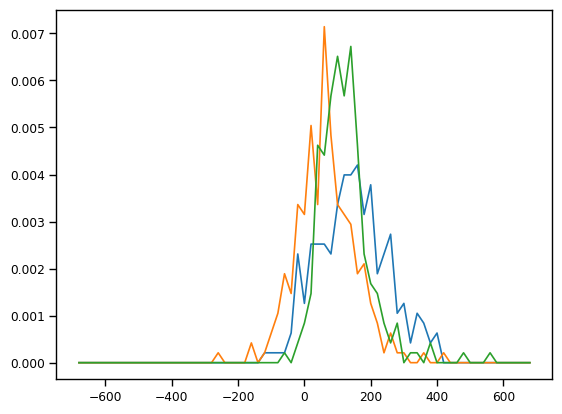

In [27]:
plt.plot(hist_divq_icon_wpacific[1][1:],hist_divq_icon_wpacific[0])
plt.plot(hist_divq_nicam_wpacific[1][1:],hist_divq_nicam_wpacific[0])
plt.plot(hist_divq_um_wpacific[1][1:],hist_divq_um_wpacific[0])

In [33]:
hist_gamma_v_icon_wpacific= np.histogram((gamma_v_mon_icon).where( 
    eq_wpacific(gamma_v_mon_icon) & (divqflux_int_mon_icon<0)),bins=np.arange(-1.5,1.5,0.1),
                                  density=True)

hist_gamma_v_nicam_wpacific= np.histogram((gamma_v_mon_nicam).where( 
    eq_wpacific(gamma_v_mon_nicam) & (divqflux_int_mon_nicam>0)),bins=np.arange(-1.5,1.5,0.1),
                                  density=True)

hist_gamma_v_um_wpacific= np.histogram((gamma_v_mon_um).where( 
    eq_wpacific(gamma_v_mon_um) & (divqflux_int_mon_um<0)),bins=np.arange(-1.5,1.5,0.1),
                                  density=True)


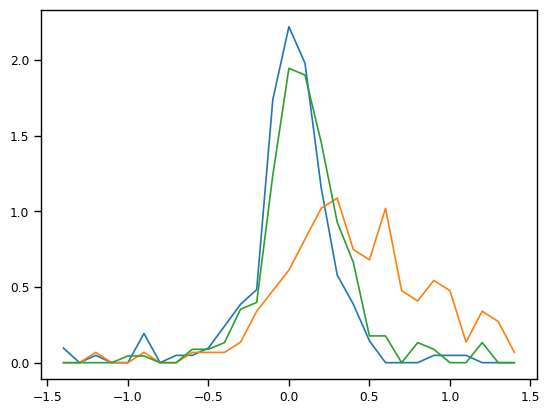

In [34]:
plt.plot(hist_gamma_v_icon_wpacific[1][1:],hist_gamma_v_icon_wpacific[0])
plt.plot(hist_gamma_v_nicam_wpacific[1][1:],hist_gamma_v_nicam_wpacific[0])
plt.plot(hist_gamma_v_um_wpacific[1][1:],hist_gamma_v_um_wpacific[0])

In [60]:
gamma_v_mon_icon

<xarray.DataArray (time: 11, cell: 49152)>
array([[-0.53505908, -0.40147204,  0.39816806, ..., -0.60933399,
         2.10322692, -0.37809855],
       [ 0.62261195,  0.2198869 ,  1.16763365, ...,  2.14359913,
        -3.09712551, -1.99547521],
       [-0.05115626,  0.2101436 ,  0.7122349 , ...,  0.7974026 ,
         1.69048719,  0.73643508],
       ...,
       [-0.33623891, -0.50922355, -0.10346616, ...,  0.03997943,
         0.09131783,  0.02817563],
       [-0.59018195, -0.97813455, -0.2259624 , ...,  1.3083913 ,
         1.02624578,  0.75000911],
       [-0.70435471, -0.95699373, -0.58007968, ...,  0.69271624,
         0.9950113 ,  3.24314239]])
Coordinates:
    lat      (cell) float64 0.5968 1.194 1.194 1.791 ... -1.194 -1.194 -0.5968
    lon      (cell) float64 45.0 45.7 44.3 45.0 ... 315.0 315.7 314.3 315.0
  * time     (time) datetime64[ns] 2020-04-30 2020-05-31 ... 2021-02-28
Dimensions without coordinates: cell

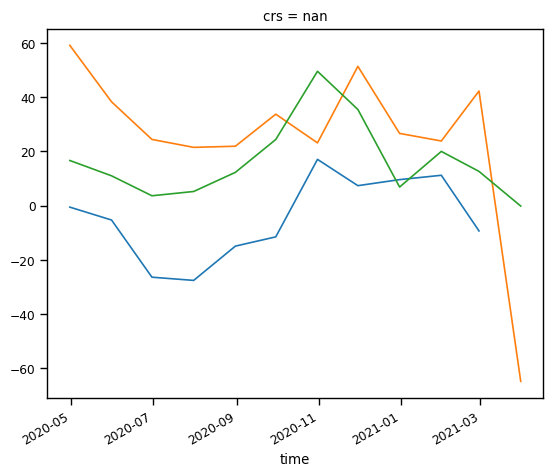

In [24]:
wdhdz_int_mon_icon.where(eq_wpacific(ds_icon)).mean('cell').plot()
(wdhdz_int_mon_nicam.where(eq_wpacific(ds_nicam)).mean('cell')).plot()
wdhdz_int_mon_um.where(eq_wpacific(ds_um)).mean('cell').plot()

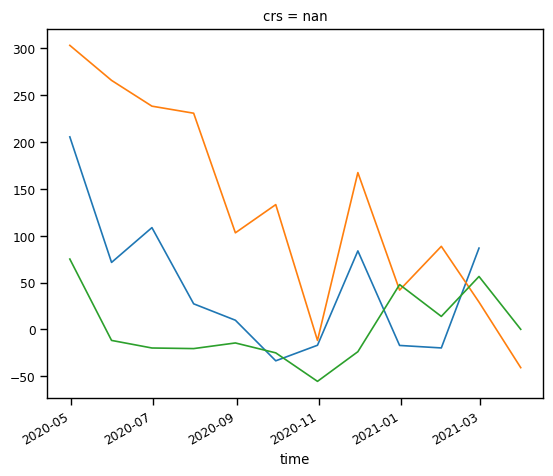

In [28]:
(divqflux_int_mon_icon.where(eq_wpacific(ds_icon)).mean('cell')*Lv*-1).plot()
(divqflux_int_mon_nicam.where(eq_wpacific(ds_nicam)).mean('cell')*Lv).plot()
(divqflux_int_mon_um.where(eq_wpacific(ds_um)).mean('cell')*Lv*-1).plot()

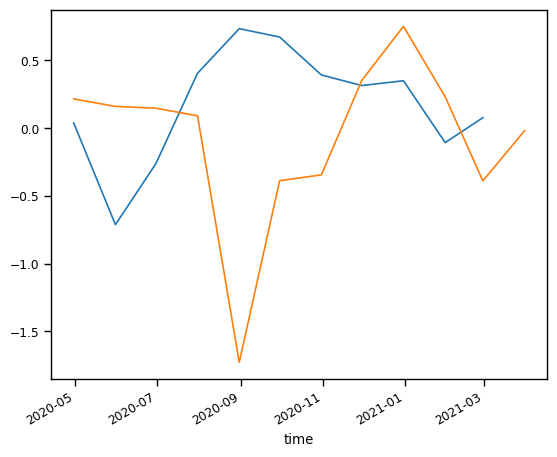

In [42]:
(wdhdz_int_mon_icon/divqflux_int_mon_icon/Lv).where(eq_wpacific(ds_icon)).mean('cell').plot()
(wdhdz_int_mon_nicam/divqflux_int_mon_nicam/Lv).where(eq_wpacific(ds_nicam)).mean('cell').plot()

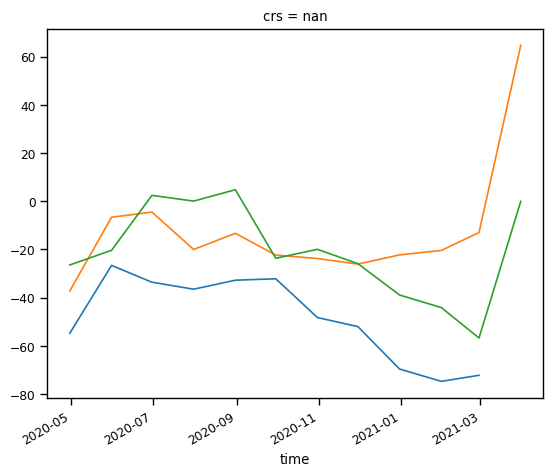

In [30]:
wdhdz_int_mon_icon.where(eq_epacific(ds_icon)).mean('cell').plot()
(wdhdz_int_mon_nicam.where(eq_epacific(ds_nicam)).mean('cell')).plot()
wdhdz_int_mon_um.where(eq_epacific(ds_um)).mean('cell').plot()

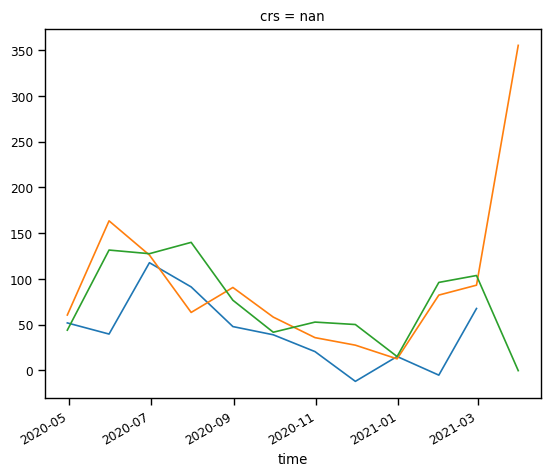

In [31]:
(divqflux_int_mon_icon.where(eq_epacific(ds_icon)).mean('cell')*Lv*-1).plot()
(divqflux_int_mon_nicam.where(eq_epacific(ds_nicam)).mean('cell')*Lv).plot()
(divqflux_int_mon_um.where(eq_epacific(ds_um)).mean('cell')*Lv*-1).plot()

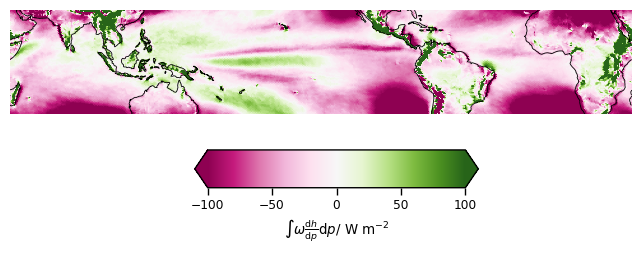

In [51]:
tropdmap(wdhdz_int_icon.mean('time'),cbar_title=r"$\int\omega\frac{\mathrm{d}h}{\mathrm{d}p}\mathrm{d}p$/ W m$^{-2}$",
         vmin=-100,vmax=100,cmap='PiYG')

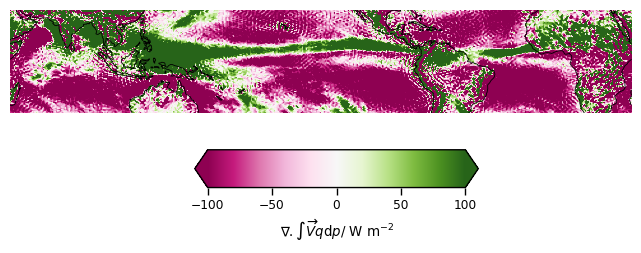

In [80]:
tropdmap(divqflux_int.mean('time')*Lv*-1,cbar_title=r"$\nabla.\int\overrightarrow{V}q\mathrm{d}p$/ W m$^{-2}$",
         vmin=-100,vmax=100,cmap='PiYG')

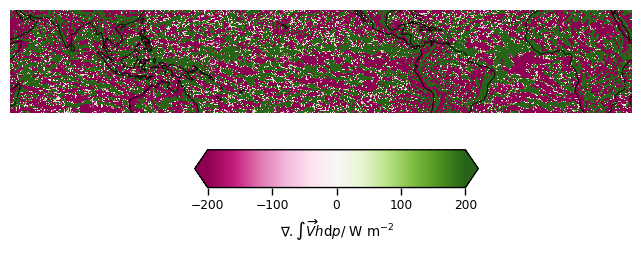

In [81]:
tropdmap(divmseflux_int.mean('time'),cbar_title=r"$\nabla.\int\overrightarrow{V}h\mathrm{d}p$/ W m$^{-2}$",
         vmin=-200,vmax=200,cmap='PiYG')

### $\Gamma$,$\Gamma_\mathrm{v}$

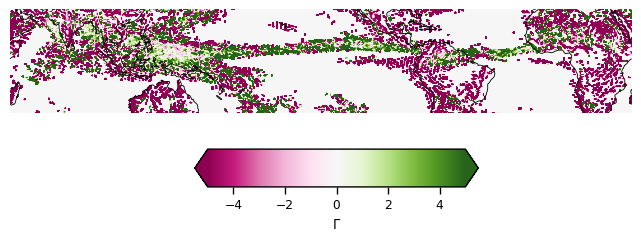

In [82]:
tropdmap(gamma_year.where(divqflux_int.mean('time')<0,0),
         cbar_title=r"$\Gamma$",vmin=-5,vmax=5,cmap='PiYG')

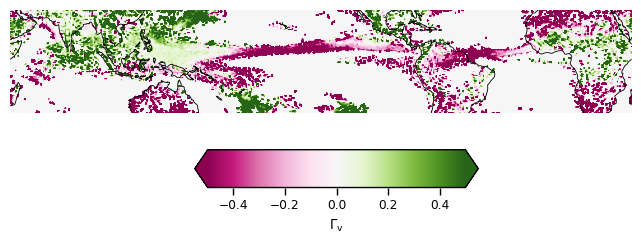

In [83]:
tropdmap(gamma_v_year.where(divqflux_int.mean('time')<0,0),
         cbar_title=r"$\Gamma_\mathrm{v}$",vmin=-0.5,vmax=0.5,cmap='PiYG')